# TransUNet for Medical Image Classification
## Cross-Dataset Comparison, All Experiments

This notebook aggregates results from all four experiments and produces the **unified comparison table and charts** used in the paper.

Run the four individual notebooks first:
1. `TransUNet_TB_Classification.ipynb`
2. `TransUNet_Pneumonia_Classification.ipynb`
3. `TransUNet_BrainTumor_Classification.ipynb`
4. `TransUNet_Melanoma_Classification.ipynb`

Each saves a `*_results_summary.csv` to its SAVE_DIR. Point the paths below to those CSVs.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# ── Point these to where each notebook saved its summary CSV ──────────────
RESULTS = [
    {
        'dataset':  'Tuberculosis',
        'modality': 'Chest X-ray',
        'csv_path': '/content/drive/MyDrive/TransUNet_Classification/Results/TB/tuberculosis_results_summary.csv'
    },
    {
        'dataset':  'Pneumonia',
        'modality': 'Chest X-ray',
        'csv_path': '/content/drive/MyDrive/TransUNet_Classification/Results/Pneumonia/pneumonia_results_summary.csv'
    },
    {
        'dataset':  'Brain Tumor',
        'modality': 'MRI',
        'csv_path': '/content/drive/MyDrive/TransUNet_Classification/Results/BrainTumor/braintumor_results_summary.csv'
    },
    {
        'dataset':  'Skin Cancer',
        'modality': 'Dermoscopy',
        'csv_path': '/content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/skin-cancer_results_summary.csv'
    },
]

OUTPUT_DIR = '/content/drive/MyDrive/TransUNet_Classification/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Config ready.')

Config ready.


In [3]:
# ── Load and merge all result CSVs ────────────────────────────────────────
rows = []
for entry in RESULTS:
    df = pd.read_csv(entry['csv_path'])
    df.insert(0, 'Dataset',  entry['dataset'])
    df.insert(1, 'Modality', entry['modality'])
    rows.append(df)

all_results = pd.concat(rows, ignore_index=True)
print(all_results.to_string(index=False))

     Dataset    Modality        Model  Accuracy (%)  F1 Score (%)  AUC-ROC (%)
Tuberculosis Chest X-ray    TransUNet         95.71         95.72        99.77
Tuberculosis Chest X-ray DenseNet-121        100.00        100.00       100.00
   Pneumonia Chest X-ray    TransUNet         97.79         97.80        99.77
   Pneumonia Chest X-ray DenseNet-121         97.79         97.80        99.90
 Brain Tumor         MRI    TransUNet         95.56         95.56        99.46
 Brain Tumor         MRI DenseNet-121         98.89         98.89        99.98
 Skin Cancer  Dermoscopy    TransUNet         85.20         85.17        94.57
 Skin Cancer  Dermoscopy DenseNet-121         90.94         90.89        97.03


In [4]:
# ── Table 1: TransUNet vs DenseNet across all datasets ────────────────────
# Pivot so TransUNet and DenseNet are side by side per dataset

transunet_rows = all_results[all_results['Model'] == 'TransUNet'].copy()
densenet_rows  = all_results[all_results['Model'] == 'DenseNet-121'].copy()

comparison = transunet_rows[['Dataset', 'Modality']].copy().reset_index(drop=True)
comparison['TransUNet Acc (%)']    = transunet_rows['Accuracy (%)'].values
comparison['TransUNet F1 (%)']     = transunet_rows['F1 Score (%)'].values
comparison['TransUNet AUC (%)']    = transunet_rows['AUC-ROC (%)'].values
comparison['DenseNet-121 Acc (%)'] = densenet_rows['Accuracy (%)'].values
comparison['DenseNet-121 F1 (%)']  = densenet_rows['F1 Score (%)'].values
comparison['DenseNet-121 AUC (%)'] = densenet_rows['AUC-ROC (%)'].values

print('=== Cross-Dataset Results Table ===')
print(comparison.to_string(index=False))

table_path = os.path.join(OUTPUT_DIR, 'cross_dataset_results_table.csv')
comparison.to_csv(table_path, index=False)
print(f'\nTable saved to: {table_path}')

=== Cross-Dataset Results Table ===
     Dataset    Modality  TransUNet Acc (%)  TransUNet F1 (%)  TransUNet AUC (%)  DenseNet-121 Acc (%)  DenseNet-121 F1 (%)  DenseNet-121 AUC (%)
Tuberculosis Chest X-ray              95.71             95.72              99.77                100.00               100.00                100.00
   Pneumonia Chest X-ray              97.79             97.80              99.77                 97.79                97.80                 99.90
 Brain Tumor         MRI              95.56             95.56              99.46                 98.89                98.89                 99.98
 Skin Cancer  Dermoscopy              85.20             85.17              94.57                 90.94                90.89                 97.03

Table saved to: /content/drive/MyDrive/TransUNet_Classification/paper_figures/cross_dataset_results_table.csv


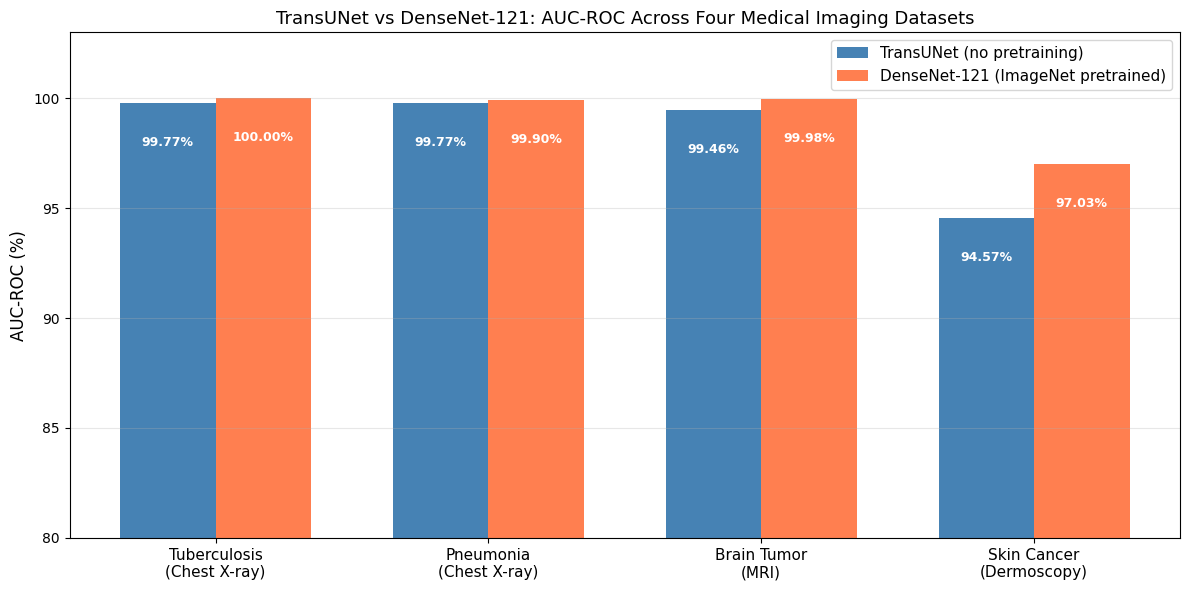

Figure saved: /content/drive/MyDrive/TransUNet_Classification/paper_figures/figure1_auc_comparison.png


In [5]:
# ── Figure 1: AUC-ROC across all datasets for both models ─────────────────
datasets   = comparison['Dataset'].tolist()
tu_aucs    = [float(v) for v in comparison['TransUNet AUC (%)'].tolist()]
dn_aucs    = [float(v) for v in comparison['DenseNet-121 AUC (%)'].tolist()]

x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, tu_aucs, width, label='TransUNet (no pretraining)', color='steelblue')
bars2 = ax.bar(x + width/2, dn_aucs, width, label='DenseNet-121 (ImageNet pretrained)', color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'{bar.get_height():.2f}%', ha='center', va='top',
            fontsize=9, color='white', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'{bar.get_height():.2f}%', ha='center', va='top',
            fontsize=9, color='white', fontweight='bold')

modalities = comparison['Modality'].tolist()
ax.set_xticks(x)
ax.set_xticklabels([f'{d}\n({m})' for d, m in zip(datasets, modalities)], fontsize=11)
ax.set_ylim([80, 103])
ax.set_ylabel('AUC-ROC (%)', fontsize=12)
ax.set_title('TransUNet vs DenseNet-121: AUC-ROC Across Four Medical Imaging Datasets', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, 'figure1_auc_comparison.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')

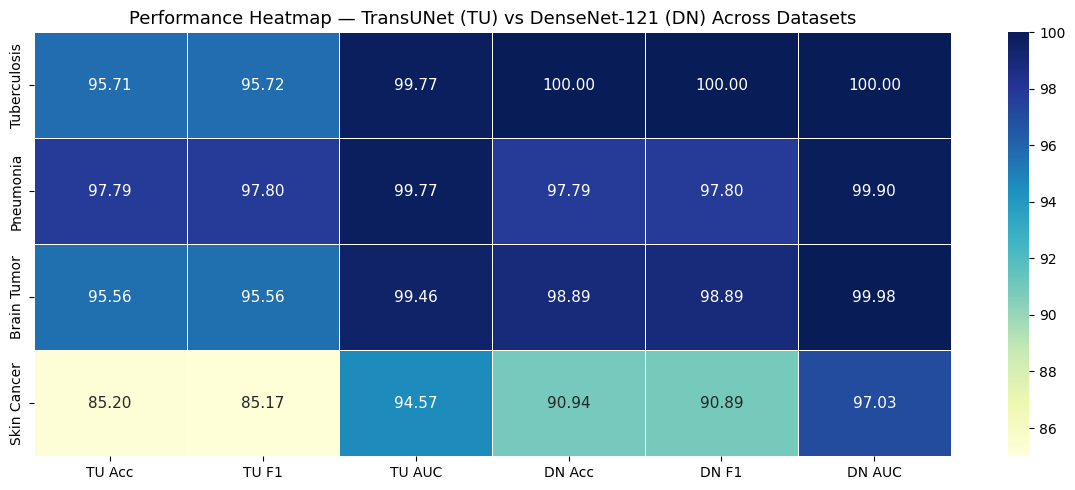

Figure saved: /content/drive/MyDrive/TransUNet_Classification/paper_figures/figure2_heatmap.png


In [6]:
# ── Figure 2: All metrics heatmap ─────────────────────────────────────────
import seaborn as sns

# Build a matrix: rows = datasets, cols = [TU Acc, TU F1, TU AUC, DN Acc, DN F1, DN AUC]
heat_data = comparison[[
    'TransUNet Acc (%)', 'TransUNet F1 (%)', 'TransUNet AUC (%)',
    'DenseNet-121 Acc (%)', 'DenseNet-121 F1 (%)', 'DenseNet-121 AUC (%)'
]].astype(float)

heat_data.index = datasets
heat_data.columns = [
    'TU Acc', 'TU F1', 'TU AUC',
    'DN Acc', 'DN F1', 'DN AUC'
]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='YlGnBu',
    vmin=85, vmax=100, linewidths=0.5, ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('Performance Heatmap — TransUNet (TU) vs DenseNet-121 (DN) Across Datasets', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, 'figure2_heatmap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')

In [7]:
# ── Print paper-ready LaTeX table ─────────────────────────────────────────
print('=== LaTeX Table (paste directly into your paper) ===\n')

print(r'\begin{table}[h]')
print(r'\centering')
print(r'\caption{Performance comparison of TransUNet and DenseNet-121 across four medical imaging datasets. TransUNet is trained from scratch; DenseNet-121 uses ImageNet pretrained weights.}')
print(r'\label{tab:results}')
print(r'\resizebox{\textwidth}{!}{')
print(r'\begin{tabular}{llcccccc}')
print(r'\hline')
print(r'\textbf{Dataset} & \textbf{Modality} & \multicolumn{3}{c}{\textbf{TransUNet (Ours)}} & \multicolumn{3}{c}{\textbf{DenseNet-121}} \\')
print(r'\cline{3-8}')
print(r' & & Acc (\%) & F1 (\%) & AUC (\%) & Acc (\%) & F1 (\%) & AUC (\%) \\')
print(r'\hline')

for _, row in comparison.iterrows():
    print(f"{row['Dataset']} & {row['Modality']} & "
          f"{row['TransUNet Acc (%)']} & {row['TransUNet F1 (%)']} & {row['TransUNet AUC (%)']} & "
          f"{row['DenseNet-121 Acc (%)']} & {row['DenseNet-121 F1 (%)']} & {row['DenseNet-121 AUC (%)']} \\\\")

print(r'\hline')
print(r'\end{tabular}}')
print(r'\end{table}')

=== LaTeX Table (paste directly into your paper) ===

\begin{table}[h]
\centering
\caption{Performance comparison of TransUNet and DenseNet-121 across four medical imaging datasets. TransUNet is trained from scratch; DenseNet-121 uses ImageNet pretrained weights.}
\label{tab:results}
\resizebox{\textwidth}{!}{
\begin{tabular}{llcccccc}
\hline
\textbf{Dataset} & \textbf{Modality} & \multicolumn{3}{c}{\textbf{TransUNet (Ours)}} & \multicolumn{3}{c}{\textbf{DenseNet-121}} \\
\cline{3-8}
 & & Acc (\%) & F1 (\%) & AUC (\%) & Acc (\%) & F1 (\%) & AUC (\%) \\
\hline
Tuberculosis & Chest X-ray & 95.71 & 95.72 & 99.77 & 100.0 & 100.0 & 100.0 \\
Pneumonia & Chest X-ray & 97.79 & 97.8 & 99.77 & 97.79 & 97.8 & 99.9 \\
Brain Tumor & MRI & 95.56 & 95.56 & 99.46 & 98.89 & 98.89 & 99.98 \\
Skin Cancer & Dermoscopy & 85.2 & 85.17 & 94.57 & 90.94 & 90.89 & 97.03 \\
\hline
\end{tabular}}
\end{table}
